# 14 — LPT spherical density: MCLMC full-posterior inference of $(\Omega_c, \sigma_8)$

Production-level field-level inference on a 1LPT → spherical galaxy-overdensity model (seed-0 mock) with **MCLMC** (BlackJAX Microcanonical Langevin Monte Carlo) sampling the *full* joint posterior over $(\Omega_c,\sigma_8)$ **and** the $\mathrm{MESH}^3$ initial-condition field. Pixel-space likelihood. Headless: `uv run --no-sync papermill 14-LPTDensityMCLMC.ipynb 14-LPTDensityMCLMC.ipynb --cwd .`

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # float32 => NaN/chaotic IC gradients
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"  # float32 => NaN/chaotic IC gradients
os.environ["HF_HOME"] = f"{os.environ['SCRATCH']}/.cache/HF"
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORMS", "cuda,cpu")
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

import time

import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
from numpyro.handlers import condition, seed, trace

import jax_fli as jfli

jax.config.update("jax_enable_x64", True)

MESH = 64  # production: MESH = 256
NSIDE = MESH
print(f"jax {jax.__version__}  backend {jax.default_backend()}  x64 {jax.config.jax_enable_x64}  MESH={MESH}")

jax 0.10.2  backend gpu  x64 True  MESH=64


## 1. Model configuration and mock observation

1LPT → spherical galaxy overdensity, two source planes at $z=0.10, 0.17$, centered observer, $z\le0.2$. Condition the pixel model on the mock and warm-start MCLMC at the truth.

In [2]:
cosmo = jc.Planck18()
box = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, 0.2, (0.5, 0.5, 0.5)))
priors = {
    "Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0),
}

config = jfli.ppl.Configurations(
    mesh_size=(MESH, MESH, MESH),
    box_size=box,
    halo_size=(0, 0),
    field_sharding=None,
    sim_mode="lpt",
    nbody_solver="BullFrog",
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=5,
    nb_steps=5,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=1.0,
    lensing_output="density",
    map2alm_method="jax",
    min_redshift=0.001,
    max_redshift=0.2,
    n_integrate=8,
    nside=NSIDE,
    geometry="spherical",
    scheme="rbf_neighbor",
    observer_position=(0.5, 0.5, 0.5),
    paint_nside=NSIDE,
    kernel_width_pixels=0.8,
    fiducial_cosmology=jc.Planck18,
    nz_shear=[0.10, 0.17],
    priors=priors,
    sigma_e=0.3,
    adjoint="checkpointed",
    checkpoints=2,
)

pixel_model = jfli.ppl.full_field_probmodel(config)
tr = trace(seed(pixel_model, 0)).get_trace()
x_obs = jnp.stack([tr[f"observable_{i}"]["value"] for i in range(2)])
x_obs_meta_data = tr["observable_meta_data"]["value"]
x_obs_field = jfli.SphericalDensity.FromDensityMetadata(array=x_obs, field=x_obs_meta_data)
theta_truth = jnp.array([float(tr["Omega_c_base"]["value"]), float(tr["sigma8_base"]["value"])])
truth_position = {
    "Omega_c_base": theta_truth[0],
    "sigma8_base": theta_truth[1],
    "initial_conditions": tr["initial_conditions"]["value"].array,
}
cond_model = condition(pixel_model, data={f"observable_{i}": x_obs[i] for i in range(2)})

# Truth Catalog = the physical IC (white field coloured at the truth cosmology, matching the chain's
# recoloured samples) + the truth cosmology. Passed to extract_catalog as the reference (true_ic +
# truth_cosmo, and for the IC transfer/coherence spectra).
truth_cosmo = tr["cosmo"]["value"]
truth_ic = jfli.interpolate_initial_conditions(
    tr["initial_conditions"]["value"].array, config.mesh_size, config.box_size, cosmo=truth_cosmo
)
truth_cat = jfli.io.Catalog(field=[truth_ic], cosmology=[truth_cosmo])

print(
    f"truth: Omega_c={float(tr['Omega_c']['value']):.4f}  sigma8={float(tr['sigma8']['value']):.4f}   joint dim = {2 + MESH**3}"
)

truth: Omega_c=0.1322  sigma8=0.8685   joint dim = 262146


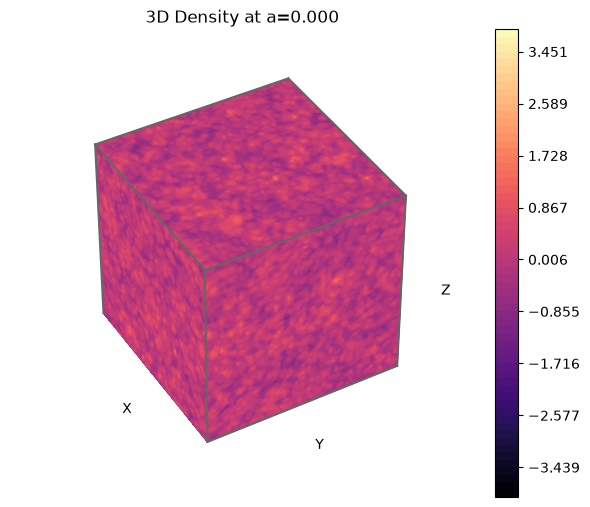

In [3]:
truth_ic.show()

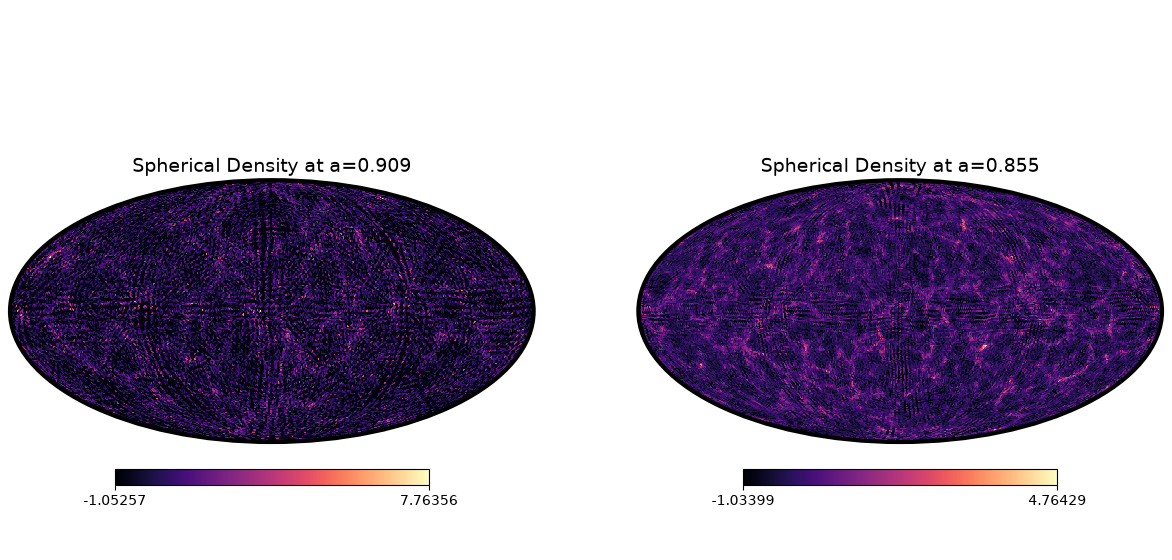

In [4]:
x_obs_field.show()

## 2. MCLMC (pixel likelihood)

Field-inference settings: `desired_energy_var=1e-7` (the 1e-3 default is for small models), `diagonal_preconditioning=True`, `init_step_size_scale=1e-4` (a plain scalar — `batched_sampling` multiplies by √dim itself), `thinning=3`. Production run: `num_warmup=num_samples=2000`; MCLMC is unadjusted, so a NaN-flagged or drifting run (`metrics.md` reports the NaN-free fraction) is a tuning failure, not a posterior. Warm-started at the truth.

In [ ]:
MCLMC_KW = dict(
    num_warmup=20,
    num_samples=10,
    batch_count=3,
    sampler="MCLMC",
    thinning=3,
    mclmc_desired_energy_var=1e-6,
    mclmc_init_step_size_scale=1e-4,
    mclmc_diagonal_preconditioning=False,
    init_params=truth_position,
    progress_bar=True,
    print_rate=2,
)

t0 = time.time()
jfli.infer.batched_sampling(
    cond_model,
    path="output/nb14/mclmc_pixel",
    rng_key=jax.random.PRNGKey(0),
    save_callback=jfli.infer.sample2catalog(config),
    post_process=jfli.infer.colour_ic(config),
    **MCLMC_KW,
)
print(f"MCLMC pixel done in {time.time() - t0:.0f}s   (output/nb14/mclmc_pixel/metrics.md)")

In [6]:
# One chain: extract the cosmology AND the IC field (mean/std) from the saved catalog, with the truth
# Catalog as the reference (fills truth_cosmo + true_ic; field_statistic reads back the recoloured IC).
mclmc = jfli.io.extract_catalog(
    set_name="MCLMC-pixel",
    cosmo_keys=["Omega_c", "sigma8"],
    patterns=["output/nb14/mclmc_pixel/samples"],
    truth=truth_cat,
    field_statistic=True,
)

for k in ("Omega_c", "sigma8"):
    m, sd = float(mclmc.cosmo[k].ravel().mean()), float(mclmc.cosmo[k].ravel().std())
    t = mclmc.truth_cosmo[k]
    print(f"{k:8s} {m:.3f} +/- {sd:.3f}   (truth {t:.3f})")
    assert abs(m - t) < max(3.0 * sd, 0.02), f"{k}={m:.3f} off truth {t:.3f} (sigma {sd:.3f})"
print("PASS: MCLMC recovers the true cosmology (within 3 sigma of its own spread, floor 0.02)")
print(f"IC extracted: mean_field {tuple(mclmc.mean_field.array.shape)}, std_field {tuple(mclmc.std_field.array.shape)}")

Generating train split: 0 examples [00:00, ? examples/s]

Omega_c  0.500 +/- 0.000   (truth 0.132)


AssertionError: Omega_c=0.500 off truth 0.132 (sigma 0.000)

In [10]:
import pyarrow.parquet as pq

pq.read_table("output/nb14/mclmc_pixel/samples/samples/samples_0.parquet")["Omega_c"]

[
  [
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5
  ]
]

In [11]:
import pyarrow.parquet as pq

pq.read_table("output/nb14/mclmc_pixel/samples/samples/samples_1.parquet")["Omega_c"]

[
  [
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5,
    0.5
  ]
]

In [7]:
mclmc.cosmo

{'Omega_c': Array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5,
         0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float64),
 'sigma8': Array([[0.60000002, 0.60000002, 0.60000002, 0.60000002, 0.60000002,
         0.60000002, 0.60000002, 0.60000002, 0.60000002, 0.60000002,
         0.60000002, 0.60000002, 0.60000002, 0.60000002, 0.60000002,
         0.60000002, 0.60000002, 0.60000002, 0.60000002, 0.60000002]],      dtype=float64)}

In [8]:
import numpy as np

dict(np.load("output/nb14/mclmc_pixel/warmup_params.npz"))

{'L': array(0.00053624), 'step_size': array(0.00080713)}

In [ ]:
jfli.infer.plot_posterior([mclmc], labels={"Omega_c": r"\Omega_c", "sigma8": r"\sigma_8"})
plt.show()

## Methods note

MCLMC samples the full $(2 + \mathrm{MESH}^3)$-dimensional joint and marginalizes $(\Omega_c,\sigma_8)$ by simply dropping the IC columns. Being unadjusted (no Metropolis correction), correctness rests on the energy-error control (`desired_energy_var`); for an adjusted variant at similar cost use `batched_sampling(sampler="MAMS")`.

## 3. Diagnostics — IC field recovery, rank & trace, ESS / R̂

`analyze` turns the single `CatalogExtract` into a full diagnostic report. Because we extracted with `field_statistic=True` against the truth `Catalog`, it renders the per-chain IC field panels — **true IC / posterior mean / std / residual** — alongside the ArviZ **rank** and **trace** plots, and prints the ESS / R̂ summary. (Needs `arviz` + `arviz-plots`; `outfolder=None` shows the figures inline, or pass a path to write a report folder.)

In [ ]:
jfli.infer.analyze(mclmc)